# De doorlooptijd (makespan) minimaliseren in een job-shop met PROC OPTMODEL


## Managementsamenvatting

Een kleine cel voor discrete productie moet vier onderdelen — een **Beugel**, een **Flens**, een **Behuizing** en een **As** — elk door een vaste reeks van drie verspaningsbewerkingen sturen, waarbij ze vier machines met enkelvoudige capaciteit delen (**Zaag**, **Frees**, **Boor**, **Slijp**). Geen enkele machine kan twee bewerkingen tegelijk uitvoeren, en de bewerkingen van elk onderdeel moeten hun technologische volgorde aanhouden. We formuleren het schema dat de doorlooptijd minimaliseert als een gemengd-geheeltallig programma in **PROC OPTMODEL** — starttijdvariabelen, klaar-tot-start voorrangsrestricties en disjunctieve (big-*M*) niet-overlaprestricties tussen elk paar bewerkingen dat een machine deelt — en lossen het op tot bewezen optimaliteit.

De MILP-solver levert een **optimale doorlooptijd van 120 minuten** op (`Solution Status = Optimal`, `Objective Value = 120`). Het resulterende schema pakt alle twaalf bewerkingen zo in dat elke machine hoogstens één onderdeel tegelijk verwerkt en elk onderdeel zijn vereiste technologische volgorde volgt. Twee bewerkingen eindigen precies op minuut 120 — het slijpen van Beugel en het frezen van Behuizing — dus zowel de Slijp- als de Frees-machine liggen op het kritieke pad dat de schemaduur vastlegt.

## Gegevensbronnen

Alle gegevens zijn in de notebook zelf gedefinieerd — geen externe bestanden of netwerk.

| Dataset | Rijen | Kernvariabelen | Beschrijving |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Eén rij per bewerking (4 onderdelen × 3 bewerkingen). `machine` (1–4) is de machine die de bewerking nodig heeft; `dur` is de verwerkingstijd in minuten; `jobname`/`mname` zijn leesbare onderdeel- en machinelabels. |
| `sched` | 12 | `op`, `start`, `finish` | OPTMODEL-uitvoer: de optimale start- en eindminuut van elke bewerking. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` samengevoegd met de opgeloste tijden, gesorteerd op machine en vervolgens start — het leesbare schema. |
| `mk` | 1 | `makespan` | De gerealiseerde doorlooptijd (laatste eindtijd). |

## Het planningsprobleem

In een **job-shop** doorlopen meerdere onderdelen ("jobs") elk een vaste reeks bewerkingen, en elke bewerking draait op een specifieke machine. Twee bewerkingen kunnen niet tegelijk dezelfde machine bezetten (de machines zijn *unaire* resources), en binnen een onderdeel moeten de bewerkingen hun technologische volgorde respecteren. De planner wil starttijden voor elke bewerking die beide regels naleven terwijl de totale schemaduur — de **doorlooptijd** (makespan) — zo klein mogelijk blijft.

Dit is een klassiek disjunctief planningsprobleem. We modelleren het als een gemengd-geheeltallig programma:

- een continue-maar-geheeltallige **starttijd** `s[o]` voor elke bewerking, en een doorlooptijdvariabele `Cmax`;
- **voorrang**: bewerking *k+1* van een onderdeel start niet eerder dan bewerking *k* eindigt;
- **disjunctieve machinecapaciteit**: voor elk paar bewerkingen dat een machine deelt beslist een binaire `y` welke eerst gaat, en een big-*M* term schakelt de inactieve volgorde uit — zodat de twee bewerkingen nooit kunnen overlappen;
- **doelfunctie**: minimaliseer `Cmax`, dat gedwongen wordt ten minste gelijk te zijn aan de eindtijd van elke bewerking.

PROC OPTMODEL is de algebraïsche modelleerprocedure van SAS/OR; de MILP-solver vindt het *aantoonbaar optimale* kortste schema.

> **Een opmerking over PROC CLP.** SAS biedt ook PROC CLP, een engine voor > constraint-logic-programming met speciale planningssyntaxis (activiteiten, > resources, voorrang). De OPTMODEL MILP-formulering hier lost het > identieke probleem op en levert een certificaat van optimaliteit, iets wat de > haalbaarheidszoektocht van CLP niet doet.

## Stap 1 — Definieer de shop-instantie

Vier onderdelen, elk drie bewerkingen, op vier machines. Elke rij legt de machine vast die een bewerking nodig heeft en de verwerkingstijd in minuten. De bewerkingen van een onderdeel staan in technologische volgorde (`opnum` 1, 2, 3).

In [1]:
GEGEVENS jobshop;
    LENGTE jobname $10 mname $6;
    INVOER op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Beugel    Zaag
2  1 2 3 40 Beugel    Boor
3  1 3 4 20 Beugel    Slijp
4  2 1 2 35 Flens     Frees
5  2 2 3 25 Flens     Boor
6  2 3 1 15 Flens     Zaag
7  3 1 3 30 Behuizing Boor
8  3 2 1 20 Behuizing Zaag
9  3 3 2 45 Behuizing Frees
10 4 1 1 20 As        Zaag
11 4 2 2 30 As        Frees
12 4 3 4 25 As        Slijp
;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=jobshop noobs label;
    TITEL 'Job-shop-instantie: 4 onderdelen, elk 3 bewerkingen, 4 machines';
    VARIABELE op jobname opnum mname dur;
    label op="Bewerking" jobname="Onderdeel" opnum="Bew.nr"
          mname="Machine" dur="Duur (min)";
UITVOEREN;

                            Job-shop-instantie: 4 onderdelen, elk 3 bewerkingen, 4 machines                             

Bewerking  Onderdeel  Bew.nr  Machine  Duur (min)
        1  Beugel          1  Zaag             25
        2  Beugel          2  Boor             40
        3  Beugel          3  Slijp            20
        4  Flens           1  Frees            35
        5  Flens           2  Boor             25
        6  Flens           3  Zaag             15
        7  Behuizing       1  Boor             30
        8  Behuizing       2  Zaag             20
        9  Behuizing       3  Frees            45
       10  As              1  Zaag             20
       11  As              2  Frees            30
       12  As              3  Slijp            25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Stap 2 — Los het schema dat de doorlooptijd minimaliseert op met PROC OPTMODEL

OPTMODEL leest de instantie in, bouwt de starttijd- en volgordevariabelen, plaatst de voorrangs- en disjunctieve restricties, en minimaliseert de doorlooptijd met de MILP-solver. De big-*M* horizon `H` is de totale werkinhoud — een veilige bovengrens voor elke starttijd. De solver rapporteert de **optimale** doelfunctie; we schrijven de gekozen start- en eindtijden weg naar `sched`.

In [2]:
PROCEDURE optmodel;
    INSTELLEN OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ GEGEVENS jobshop INTO OPS=[op] job opnum machine dur;

    /* een veilige big-M-horizon = totale werkinhoud */
    num H = sum{o in OPS} dur[o];

    VARIABELE s{OPS} >= 0 integer;     /* starttijd bewerking (minuten) */
    VARIABELE Cmax >= 0;               /* doorlooptijd */

    /* technologische volgorde: bewerking k+1 start nadat bewerking k eindigt */
    con prec{a in OPS, b in OPS:
             job[a] = job[b] AND opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* doorlooptijd domineert de eindtijd van elke bewerking */
    con span{o in OPS}: Cmax >= s[o] + dur[o];

    /* disjunctieve machinecapaciteit: voor elk paar bewerkingen dat een
       machine deelt legt de binaire y de volgorde vast; big-M ontspant de andere */
    VARIABELE y{a in OPS, b in OPS:
          a < b AND machine[a] = machine[b]} binary;
    con seqAB{a in OPS, b in OPS:
              a < b AND machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a in OPS, b in OPS:
              a < b AND machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o in OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREATE GEGEVENS sched FROM
        [op]={o in OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                            Job-shop-instantie: 4 onderdelen, elk 3 bewerkingen, 4 machines                             


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Stap 3 — Stel het leesbare schema samen

Voeg de opgeloste tijden terug bij de onderdeel- en machinelabels, sorteer op machine en vervolgens starttijd, en druk het schema af. De doorlooptijd is de grootste eindtijd over alle bewerkingen.

In [3]:
PROCEDURE SORTEREN GEGEVENS=jobshop out=jobs2; VOLGENS op; UITVOEREN;
PROCEDURE SORTEREN GEGEVENS=sched   out=sol;   VOLGENS op; UITVOEREN;

GEGEVENS schedule;
    SAMENVOEGEN jobs2 sol;
    VOLGENS op;
UITVOEREN;

PROCEDURE SORTEREN GEGEVENS=schedule; VOLGENS mname START; UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=schedule noobs label;
    TITEL 'Optimaal schema: start/einde (minuten) van elke bewerking';
    VARIABELE jobname opnum mname dur START FINISH;
    label jobname="Onderdeel" opnum="Bew.nr" mname="Machine"
          dur="Duur (min)" start="Start (min)" finish="Einde (min)";
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=schedule MAX NOPRINT;
    VARIABELE FINISH;
    UITVOER out=mk(VERWIJDEREN=_type_ _freq_) MAX=makespan;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=mk noobs label;
    TITEL 'Minimale doorlooptijd (laatste bewerkingseinde, minuten)';
    label makespan="Doorlooptijd (min)";
UITVOEREN;

                               Optimaal schema: start/einde (minuten) van elke bewerking                                

Onderdeel  Bew.nr  Machine  Duur (min)  Start (min)  Einde (min)
Behuizing       1  Boor             30            0           30
Flens           2  Boor             25           35           60
Beugel          2  Boor             40           60          100
Flens           1  Frees            35            0           35
As              2  Frees            30           35           65
Behuizing       3  Frees            45           75          120
As              3  Slijp            25           65           90
Beugel          3  Slijp            20          100          120
As              1  Zaag             20            0           20
Beugel          1  Zaag             25           20           45
Behuizing       2  Zaag             20           45           65
Flens           3  Zaag             15           65           80

                                


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Stap 4 — Visualiseer het schema

We geven elke bewerking een rangordelijk **slot** (gesorteerd op machine en vervolgens start) en tekenen het tijdvenster als een zwevende balk: de balk loopt van de startminuut tot de eindminuut van de bewerking. Slots 1–3 zijn de Boor, 4–6 de Frees, 7–8 de Slijp en 9–12 de Zaag. De tabel er direct onder benoemt het onderdeel in elk slot, zodat de grafiek en de tabel samen te lezen zijn. Balken op dezelfde machine overlappen elkaar nooit in de tijd — de disjunctieve restrictie zichtbaar gemaakt.

                          Schema per slot (slotvolgorde komt overeen met de grafiek hieronder)                          

Slot  Machine  Onderdeel  Start (min)  Einde (min)
   1  Boor     Behuizing            0           30
   2  Boor     Flens               35           60
   3  Boor     Beugel              60          100
   4  Frees    Flens                0           35
   5  Frees    As                  35           65
   6  Frees    Behuizing           75          120
   7  Slijp    As                  65           90
   8  Slijp    Beugel             100          120
   9  Zaag     As                   0           20
  10  Zaag     Beugel              20           45
  11  Zaag     Behuizing           45           65
  12  Zaag     Flens               65           80

                          Schema per slot (slotvolgorde komt overeen met de grafiek hieronder)                          




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


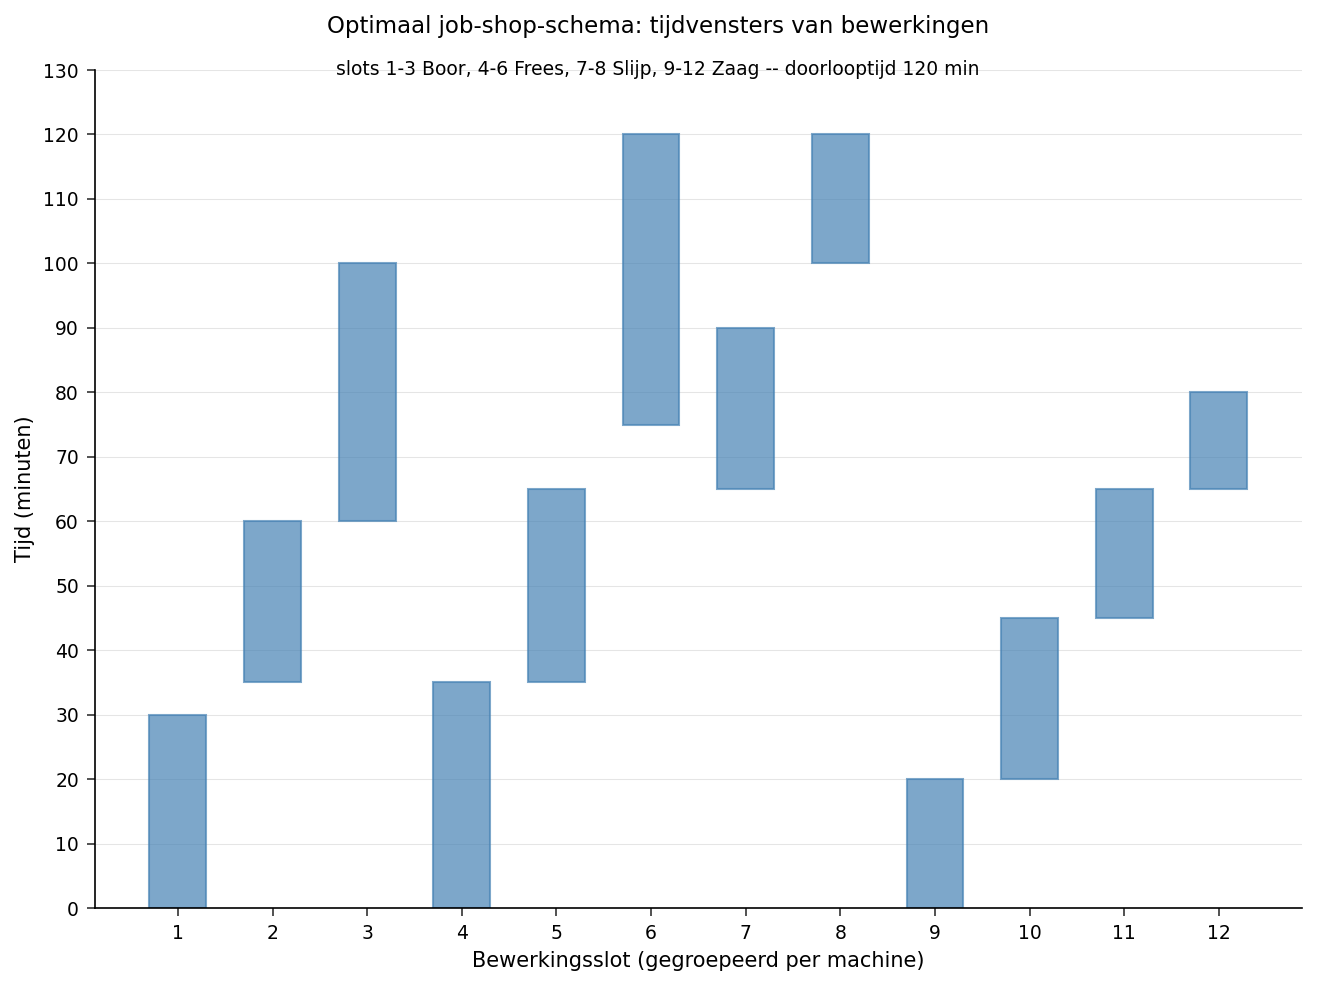

In [4]:
GEGEVENS ganttdata;
    INSTELLEN schedule;
    slot + 1;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=ganttdata noobs label;
    TITEL 'Schema per slot (slotvolgorde komt overeen met de grafiek hieronder)';
    VARIABELE slot mname jobname START FINISH;
    label slot="Slot" mname="Machine" jobname="Onderdeel"
          start="Start (min)" finish="Einde (min)";
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=ganttdata noautolegend;
    TITEL 'Optimaal job-shop-schema: tijdvensters van bewerkingen';
    title2 'slots 1-3 Boor, 4-6 Frees, 7-8 Slijp, 9-12 Zaag -- doorlooptijd 120 min';
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS label='Bewerkingsslot (gegroepeerd per machine)' integer
          VALUES=(1 TOT 12 VOLGENS 1);
    YAXIS label='Tijd (minuten)' grid VALUES=(0 TOT 130 VOLGENS 10);
UITVOEREN;
TITEL;

## De resultaten interpreteren

- **Optimaliteit.** De MILP-solver leverde `Solution Status = Optimal` op met `Objective Value = 120`, dus **120 minuten is de aantoonbaar kortst mogelijke doorlooptijd** voor deze instantie — geen enkel schema kan eerder klaar zijn. Dit certificaat is wat de mathematisch-programmeringsformulering je oplevert boven een pure haalbaarheidszoektocht.

- **Het schema respecteert elke restrictie.** Uit de tabel per machine blijkt dat geen twee bewerkingen op dezelfde machine overlappen (bijv. op de Zaag: As 0–20, Beugel 20–45, Behuizing 45–65, Flens 65–80), en dat elk onderdeel in technologische volgorde draait (bijv. Behuizing: Boor 0–30, dan Zaag 45–65, dan Frees 75–120). De grafiek met zwevende balken toont hetzelfde: binnen de slotband van elke machine tegelen de tijdvensters zonder botsing.

- **Wat de schemaduur bepaalt.** Twee bewerkingen eindigen precies op minuut 120 — de Slijp van Beugel (slot 8) en de Frees van Behuizing (slot 6). Beide raken de doorlooptijd, dus de Slijp- en Frees-machine liggen op het kritieke pad; de doorlooptijd verder inkorten zou vereisen dat je de instantie zelf verandert (snellere bewerkingen, een extra machine of versoepelde voorrang), niet louter herordenen.

- **Hoe het opschaalt.** De formulering groeit vanzelf mee: voeg een machine toe als nog een waarde van `machine`, voeg onderdelen toe als meer rijen van `jobshop`, of modelleer vrijgave- en vervaldata door `s[o]` te begrenzen en vervaldatumrestricties toe te voegen. Toestaan dat een machine meerdere jobs tegelijk uitvoert (capaciteit >1) vervangt de paarsgewijze disjunctie door een cumulatieve-resourcerestrictie. Dezelfde OPTMODEL MILP hanteert dan rijkere werkvloerregels zonder de solver te veranderen.